In [1]:
# Librerías necesarias
%pip install -q numpy pandas scipy scikit-learn imbalanced-learn matplotlib joblib

Note: you may need to restart the kernel to use updated packages.


In [2]:
#Importamos lo correspondiente
import os
import json
import random
import hashlib
import platform
import warnings

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
import imblearn

from scipy import stats

from sklearn.base import clone

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate,
    cross_val_predict,
)

from sklearn.pipeline import Pipeline

from sklearn.feature_selection import VarianceThreshold

from sklearn.preprocessing import (
    StandardScaler,
)

from sklearn.impute import (
    SimpleImputer,
)

from sklearn.svm import SVC

from sklearn.calibration import (
    CalibratedClassifierCV,
    calibration_curve,
)

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    classification_report,
    make_scorer,
    RocCurveDisplay,
    PrecisionRecallDisplay,
    ConfusionMatrixDisplay,
)

from imblearn.over_sampling import SMOTE

from imblearn.under_sampling import (
    RandomUnderSampler,
)

from imblearn.pipeline import Pipeline as ImbPipeline

from joblib import dump, load

warnings.filterwarnings("ignore")

print("Importaciones listas.")

Importaciones listas.


##Semillas y demás de reproducibilidad

In [3]:
SEED = 4524

os.environ["PYTHONHASHSEED"] = str(SEED)

random.seed(SEED)
np.random.seed(SEED)

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)
pd.set_option("display.float_format", lambda x: f"{x:.4f}")

print("Semilla global:", SEED)
print("Python:", platform.python_version())
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("imbalanced-learn:", imblearn.__version__)

Semilla global: 4524
Python: 3.12.3
NumPy: 2.5.1
Pandas: 2.3.3
scikit-learn: 1.9.0
imbalanced-learn: 0.14.2


In [4]:
#Google drive
from google.colab import drive

drive.mount("/content/drive")

ModuleNotFoundError: No module named 'google'

In [ ]:
#Montamos las rutas
candidate_project_dirs = [
    Path("/content/drive/MyDrive/Quantathon"),
    Path("/content/drive/MyDrive/Quanthaton"),
]

PROJECT_DIR = next(
    (
        path
        for path in candidate_project_dirs
        if path.exists()
    ),
    None,
)

assert PROJECT_DIR is not None, (
    "No se encontró la carpeta Quantathon o Quanthaton "
    "dentro de MyDrive."
)

TRAINING_CSV = (
    PROJECT_DIR
    / "water_potability_complete_cases.csv"
)

EXTERNAL_21_CSV = (
    PROJECT_DIR
    / "ircach_21_muestras_completas_4_features_labeled.csv"
)

EXTERNAL_14_CSV = (
    PROJECT_DIR
    / "ircach_14_muestras_completas_5_features_labeled.csv"
)

print("Carpeta del proyecto:")
print(PROJECT_DIR)

print("\nArchivos esperados:")
print("Training:", TRAINING_CSV)
print("IRCACH 21:", EXTERNAL_21_CSV)
print("IRCACH 14:", EXTERNAL_14_CSV)

#Y comprobamos los archivos
files_to_check = {
    "Training complete cases": TRAINING_CSV,
    "IRCACH 21 muestras / 4F": EXTERNAL_21_CSV,
    "IRCACH 14 muestras / 5F": EXTERNAL_14_CSV,
}

for file_name, file_path in files_to_check.items():

    exists = file_path.exists()

    print(
        f"{file_name}: "
        f"{'ENCONTRADO' if exists else 'NO ENCONTRADO'}"
    )

    if exists:
        size_kb = file_path.stat().st_size / 1024

        print(
            f"  Archivo: {file_path.name}"
        )

        print(
            f"  Tamaño: {size_kb:.2f} KB"
        )

assert TRAINING_CSV.exists(), (
    f"No se encontró: {TRAINING_CSV}"
)

assert EXTERNAL_21_CSV.exists(), (
    f"No se encontró: {EXTERNAL_21_CSV}"
)

assert EXTERNAL_14_CSV.exists(), (
    f"No se encontró: {EXTERNAL_14_CSV}"
)

Carpeta del proyecto:
/content/drive/MyDrive/Quanthaton

Archivos esperados:
Training: /content/drive/MyDrive/Quanthaton/water_potability_complete_cases.csv
IRCACH 21: /content/drive/MyDrive/Quanthaton/ircach_21_muestras_completas_4_features_labeled.csv
IRCACH 14: /content/drive/MyDrive/Quanthaton/ircach_14_muestras_completas_5_features_labeled.csv
Training complete cases: ENCONTRADO
  Archivo: water_potability_complete_cases.csv
  Tamaño: 351.36 KB
IRCACH 21 muestras / 4F: ENCONTRADO
  Archivo: ircach_21_muestras_completas_4_features_labeled.csv
  Tamaño: 3.55 KB
IRCACH 14 muestras / 5F: ENCONTRADO
  Archivo: ircach_14_muestras_completas_5_features_labeled.csv
  Tamaño: 2.54 KB


In [ ]:
#Cargamos los csv
df_water_complete = pd.read_csv(
    TRAINING_CSV
)

df_ircach_21 = pd.read_csv(
    EXTERNAL_21_CSV
)

df_ircach_14 = pd.read_csv(
    EXTERNAL_14_CSV
)

print(
    "Water complete cases:",
    df_water_complete.shape
)

print(
    "IRCACH 21:",
    df_ircach_21.shape
)

print(
    "IRCACH 14:",
    df_ircach_14.shape
)

Water complete cases: (2011, 11)
IRCACH 21: (21, 16)
IRCACH 14: (14, 17)


In [ ]:
#Definimos de una vez las 4 features
FEATURES_MAIN = [
    "ph",
    "Hardness",
    "Sulfate",
    "Conductivity",
]

TARGET = "Potability"

print("Features principales:")

for feature in FEATURES_MAIN:
    print("-", feature)

print("\nTarget:", TARGET)
#Verificamos las columnas+

required_training_columns = (
    FEATURES_MAIN
    + [TARGET]
)

required_external_columns = (
    FEATURES_MAIN
    + [TARGET]
)

missing_training = [
    column
    for column in required_training_columns
    if column not in df_water_complete.columns
]

missing_external = [
    column
    for column in required_external_columns
    if column not in df_ircach_21.columns
]

assert not missing_training, (
    f"Faltan columnas en training: "
    f"{missing_training}"
)

assert not missing_external, (
    f"Faltan columnas en IRCACH 21: "
    f"{missing_external}"
)

print("Columnas requeridas encontradas correctamente.")

print("\nColumnas del training:")
print(df_water_complete.columns.tolist())

print("\nColumnas del panel IRCACH 21:")
print(df_ircach_21.columns.tolist())

Features principales:
- ph
- Hardness
- Sulfate
- Conductivity

Target: Potability
Columnas requeridas encontradas correctamente.

Columnas del training:
['Sample_ID', 'ph', 'Hardness', 'Solids', 'Chloramines', 'Sulfate', 'Conductivity', 'Organic_carbon', 'Trihalomethanes', 'Turbidity', 'Potability']

Columnas del panel IRCACH 21:
['External_ID', 'IRCACH_example', 'PDF_page', 'AYA_ID', 'system_type', 'system_name', 'sampling_point', 'sampling_date', 'ph', 'Hardness', 'Sulfate', 'Conductivity', 'IRCACH_score', 'IRCACH_risk_level', 'IRCACH_quality', 'Potability']


In [ ]:
#Creamos las tablas impolutas
df_model = (
    df_water_complete[
        FEATURES_MAIN + [TARGET]
    ]
    .copy()
)

df_external = (
    df_ircach_21[
        FEATURES_MAIN + [TARGET]
    ]
    .copy()
)

print("Dataset de desarrollo:")
print(df_model.shape)

print("\nPanel externo congelado:")
print(df_external.shape)

display(
    df_model.head()
)

display(
    df_external.head()
)

Dataset de desarrollo:
(2011, 5)

Panel externo congelado:
(21, 5)


,ph,Hardness,Sulfate,Conductivity,Potability
0,8.3168,214.3734,356.8861,363.2665,0
1,9.0922,181.1015,310.1357,398.4108,0
2,5.5841,188.3133,326.6784,280.4679,0
3,10.2239,248.0717,393.6634,283.6516,0
4,8.6358,203.3615,303.3098,474.6076,0


,ph,Hardness,Sulfate,Conductivity,Potability
0,7.0800,56.0000,2.1300,103.0000,0
1,7.4700,6367.0000,297.3300,11090.0000,0
2,6.8300,46.0000,2.0200,126.0000,1
3,4.6500,10.0000,17.2900,115.0000,0
4,7.7200,22.0000,22.1000,76.0000,0


##Parte del modelado.

In [ ]:
#Hacemos un split estratificado relación 80/20
all_indices = np.arange(len(df_model))

train_indices, test_indices = train_test_split(
    all_indices,
    test_size=0.20,
    stratify=df_model[TARGET],
    random_state=SEED,
    shuffle=True,
)

X_train = (
    df_model
    .iloc[train_indices][FEATURES_MAIN]
    .copy()
)

X_test = (
    df_model
    .iloc[test_indices][FEATURES_MAIN]
    .copy()
)

y_train = (
    df_model
    .iloc[train_indices][TARGET]
    .astype(int)
    .copy()
)

y_test = (
    df_model
    .iloc[test_indices][TARGET]
    .astype(int)
    .copy()
)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (1608, 4)
X_test:  (403, 4)
y_train: (1608,)
y_test:  (403,)


In [ ]:
#Observamos como nos salío la estratificación
def class_distribution(y, name):

    counts = (
        pd.Series(y)
        .value_counts()
        .sort_index()
    )

    percentages = (
        pd.Series(y)
        .value_counts(normalize=True)
        .sort_index()
        .mul(100)
    )

    summary = pd.DataFrame({
        "Dataset": name,
        "Clase": counts.index,
        "n": counts.values,
        "Porcentaje": percentages.values,
    })

    return summary


split_distribution = pd.concat(
    [
        class_distribution(
            df_model[TARGET],
            "Dataset completo",
        ),
        class_distribution(
            y_train,
            "Training",
        ),
        class_distribution(
            y_test,
            "Test",
        ),
    ],
    ignore_index=True,
)

display(
    split_distribution.round(2)
)

assert len(
    set(train_indices).intersection(
        set(test_indices)
    )
) == 0

assert len(train_indices) + len(test_indices) == len(df_model)

assert X_train.isna().sum().sum() == 0
assert X_test.isna().sum().sum() == 0

assert set(y_train.unique()) == {0, 1}
assert set(y_test.unique()) == {0, 1}

assert list(X_train.columns) == FEATURES_MAIN
assert list(X_test.columns) == FEATURES_MAIN

print("Split correcto.")
print("Solapamiento train/test: 0")
print("NaN en train:", X_train.isna().sum().sum())
print("NaN en test:", X_test.isna().sum().sum())

,Dataset,Clase,n,Porcentaje
0,Dataset completo,0,1200,59.6700
1,Dataset completo,1,811,40.3300
2,Training,0,960,59.7000
3,Training,1,648,40.3000
4,Test,0,240,59.5500
5,Test,1,163,40.4500


Split correcto.
Solapamiento train/test: 0
NaN en train: 0
NaN en test: 0


In [ ]:
#Preparamos el SVMRBF original
baseline_svm = Pipeline(
    steps=[
        (
            "variance",
            VarianceThreshold(
                threshold=0.0
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "svm",
            SVC(
                kernel="rbf",
                C=1.0,
                gamma="scale",
                class_weight=None,
                probability=False,
                random_state=SEED,
            ),
        ),
    ]
)

baseline_svm

baseline_svm.fit(
    X_train,
    y_train,
)

y_train_pred = baseline_svm.predict(
    X_train
)

y_test_pred = baseline_svm.predict(
    X_test
)

y_train_score = baseline_svm.decision_function(
    X_train
)

y_test_score = baseline_svm.decision_function(
    X_test
)

print("Baseline SVM-RBF entrenado.")

Baseline SVM-RBF entrenado.


In [ ]:
#Calibramos para brier score
calibration_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

calibrated_svm = CalibratedClassifierCV(
    estimator=clone(baseline_svm),
    method="sigmoid",
    cv=calibration_cv,
    n_jobs=-1,
)

calibrated_svm.fit(
    X_train,
    y_train,
)

y_train_probability = calibrated_svm.predict_proba(
    X_train
)[:, 1]

y_test_probability = calibrated_svm.predict_proba(
    X_test
)[:, 1]

print("Probabilidades calibradas.")
print(
    "Rango test:",
    round(y_test_probability.min(), 4),
    "—",
    round(y_test_probability.max(), 4),
)

Probabilidades calibradas.
Rango test: 0.1921 — 0.9035


##Métricas

,Dataset,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,ROC_AUC,Brier_Score,TN,FP,FN,TP
0,Training,0.6940,0.6399,0.7500,0.3611,0.4875,0.3471,0.7457,0.1982,882,78,414,234
1,Test,0.6526,0.6030,0.6292,0.3436,0.4444,0.2438,0.6852,0.2170,207,33,107,56


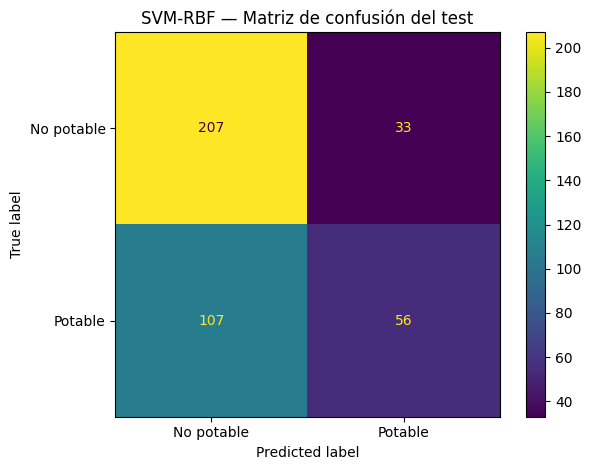

              precision    recall  f1-score   support

  No potable     0.6592    0.8625    0.7473       240
     Potable     0.6292    0.3436    0.4444       163

    accuracy                         0.6526       403
   macro avg     0.6442    0.6030    0.5959       403
weighted avg     0.6471    0.6526    0.6248       403



In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    matthews_corrcoef,
    roc_auc_score,
    brier_score_loss,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)


def evaluate_binary_classifier(
    y_true,
    y_pred,
    y_score,
    y_probability,
    dataset_name,
):
    tn, fp, fn, tp = confusion_matrix(
        y_true,
        y_pred,
        labels=[0, 1],
    ).ravel()

    results = {
        "Dataset": dataset_name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Balanced_Accuracy": balanced_accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "ROC_AUC": roc_auc_score(y_true, y_score),
        "Brier_Score": brier_score_loss(y_true, y_probability),
        "TN": tn,
        "FP": fp,
        "FN": fn,
        "TP": tp,
    }

    return results


baseline_results = pd.DataFrame(
    [
        evaluate_binary_classifier(
            y_true=y_train,
            y_pred=y_train_pred,
            y_score=y_train_score,
            y_probability=y_train_probability,
            dataset_name="Training",
        ),
        evaluate_binary_classifier(
            y_true=y_test,
            y_pred=y_test_pred,
            y_score=y_test_score,
            y_probability=y_test_probability,
            dataset_name="Test",
        ),
    ]
)

display(baseline_results.round(4))


ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_test_pred,
    labels=[0, 1],
    display_labels=[
        "No potable",
        "Potable",
    ],
    values_format="d",
)

plt.title("SVM-RBF — Matriz de confusión del test")
plt.tight_layout()
plt.show()


print(
    classification_report(
        y_test,
        y_test_pred,
        labels=[0, 1],
        target_names=[
            "No potable",
            "Potable",
        ],
        digits=4,
        zero_division=0,
    )
)

##Validaciones

In [ ]:
#validación crossvalidation5fold
from sklearn.metrics import make_scorer

cv_5fold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

cv_scoring = {
    "Accuracy": "accuracy",
    "Balanced_Accuracy": "balanced_accuracy",
    "Precision": "precision",
    "Recall": "recall",
    "F1": "f1",
    "MCC": make_scorer(matthews_corrcoef),
    "ROC_AUC": "roc_auc",
}

cv_results = cross_validate(
    estimator=clone(baseline_svm),
    X=X_train,
    y=y_train,
    cv=cv_5fold,
    scoring=cv_scoring,
    n_jobs=-1,
    return_train_score=False,
    error_score="raise",
)

cv_fold_table = pd.DataFrame({
    metric: cv_results[f"test_{metric}"]
    for metric in cv_scoring
})

cv_fold_table.index = [
    f"Fold_{i}"
    for i in range(1, 6)
]

display(
    cv_fold_table.round(4)
)
cv_summary = pd.DataFrame({
    "Mean": cv_fold_table.mean(),
    "SD": cv_fold_table.std(ddof=1),
    "Minimum": cv_fold_table.min(),
    "Maximum": cv_fold_table.max(),
})

display(
    cv_summary.round(4)
)

,Accuracy,Balanced_Accuracy,Precision,Recall,F1,MCC,ROC_AUC
Fold_1,0.6460,0.5851,0.6481,0.2692,0.3804,0.2236,0.6591
Fold_2,0.6366,0.5885,0.5867,0.3385,0.4293,0.2055,0.6449
Fold_3,0.6863,0.6277,0.7636,0.3231,0.4541,0.3329,0.7224
Fold_4,0.6854,0.6352,0.7000,0.3798,0.4925,0.3211,0.7247
Fold_5,0.6760,0.6211,0.6984,0.3411,0.4583,0.2989,0.6886


,Mean,SD,Minimum,Maximum
Accuracy,0.6661,0.0232,0.6366,0.6863
Balanced_Accuracy,0.6115,0.0231,0.5851,0.6352
Precision,0.6794,0.0661,0.5867,0.7636
Recall,0.3303,0.0401,0.2692,0.3798
F1,0.4429,0.0416,0.3804,0.4925
MCC,0.2764,0.0581,0.2055,0.3329
ROC_AUC,0.6879,0.0361,0.6449,0.7247


In [ ]:
#Métrica de brier scoree
calibrated_model_for_cv = CalibratedClassifierCV(
    estimator=clone(baseline_svm),
    method="sigmoid",
    cv=3,
    n_jobs=-1,
)

brier_cv_results = cross_validate(
    estimator=calibrated_model_for_cv,
    X=X_train,
    y=y_train,
    cv=cv_5fold,
    scoring="neg_brier_score",
    n_jobs=-1,
    error_score="raise",
)

brier_by_fold = -brier_cv_results[
    "test_score"
]

brier_cv_summary = pd.DataFrame({
    "Fold": [
        f"Fold_{i}"
        for i in range(1, 6)
    ],
    "Brier_Score": brier_by_fold,
})

display(
    brier_cv_summary.round(4)
)

print(
    "Brier CV:",
    f"{brier_by_fold.mean():.4f}",
    "±",
    f"{brier_by_fold.std(ddof=1):.4f}",
)

,Fold,Brier_Score
0,Fold_1,0.2170
1,Fold_2,0.2269
2,Fold_3,0.2081
3,Fold_4,0.2004
4,Fold_5,0.2119


Brier CV: 0.2129 ± 0.0099


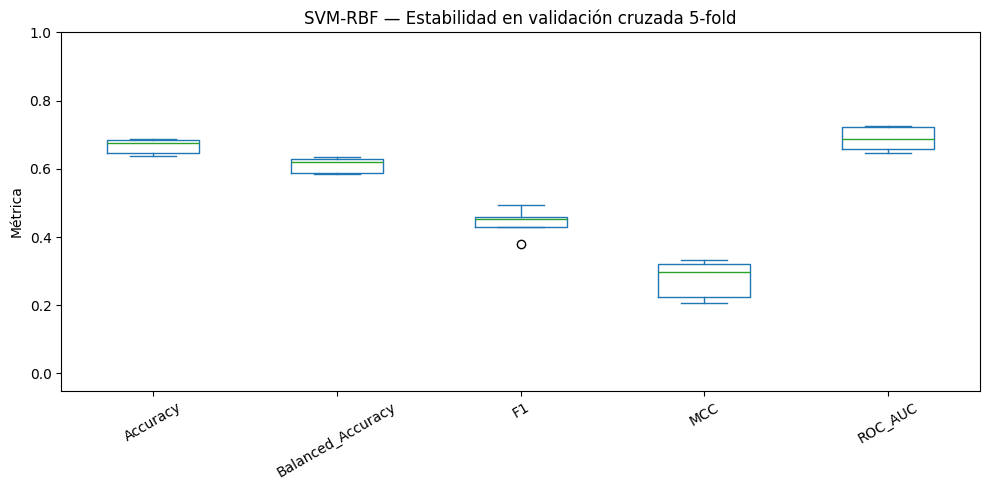

In [ ]:
#Visualiamos la estabilidad entre folds
metrics_to_plot = [
    "Accuracy",
    "Balanced_Accuracy",
    "F1",
    "MCC",
    "ROC_AUC",
]

ax = cv_fold_table[
    metrics_to_plot
].plot(
    kind="box",
    figsize=(10, 5),
)

ax.set_title(
    "SVM-RBF — Estabilidad en validación cruzada 5-fold"
)

ax.set_ylabel("Métrica")
ax.set_ylim(-0.05, 1.00)

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
#El famoso bootstrap con n igual a 1000, para observar la incertidumbre de las métricas sobre el cojunto test.
N_BOOTSTRAP = 1000

rng_bootstrap = np.random.default_rng(
    SEED
)

y_test_array = np.asarray(
    y_test,
    dtype=int,
)

y_test_pred_array = np.asarray(
    y_test_pred,
    dtype=int,
)

y_test_score_array = np.asarray(
    y_test_score,
    dtype=float,
)

y_test_probability_array = np.asarray(
    y_test_probability,
    dtype=float,
)

indices_class_0 = np.where(
    y_test_array == 0
)[0]

indices_class_1 = np.where(
    y_test_array == 1
)[0]

bootstrap_rows = []

for bootstrap_id in range(N_BOOTSTRAP):

    sampled_class_0 = rng_bootstrap.choice(
        indices_class_0,
        size=len(indices_class_0),
        replace=True,
    )

    sampled_class_1 = rng_bootstrap.choice(
        indices_class_1,
        size=len(indices_class_1),
        replace=True,
    )

    sampled_indices = np.concatenate([
        sampled_class_0,
        sampled_class_1,
    ])

    rng_bootstrap.shuffle(
        sampled_indices
    )

    y_true_boot = y_test_array[
        sampled_indices
    ]

    y_pred_boot = y_test_pred_array[
        sampled_indices
    ]

    y_score_boot = y_test_score_array[
        sampled_indices
    ]

    y_probability_boot = y_test_probability_array[
        sampled_indices
    ]

    bootstrap_rows.append({
        "Bootstrap_ID": bootstrap_id + 1,

        "Accuracy":
            accuracy_score(
                y_true_boot,
                y_pred_boot,
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_true_boot,
                y_pred_boot,
            ),

        "Precision":
            precision_score(
                y_true_boot,
                y_pred_boot,
                zero_division=0,
            ),

        "Recall":
            recall_score(
                y_true_boot,
                y_pred_boot,
                zero_division=0,
            ),

        "F1":
            f1_score(
                y_true_boot,
                y_pred_boot,
                zero_division=0,
            ),

        "MCC":
            matthews_corrcoef(
                y_true_boot,
                y_pred_boot,
            ),

        "ROC_AUC":
            roc_auc_score(
                y_true_boot,
                y_score_boot,
            ),

        "Brier_Score":
            brier_score_loss(
                y_true_boot,
                y_probability_boot,
            ),
    })

bootstrap_results = pd.DataFrame(
    bootstrap_rows
)

print(
    "Réplicas completadas:",
    len(bootstrap_results)
)

bootstrap_metrics = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "ROC_AUC",
    "Brier_Score",
]

observed_values = {
    "Accuracy":
        accuracy_score(
            y_test,
            y_test_pred,
        ),

    "Balanced_Accuracy":
        balanced_accuracy_score(
            y_test,
            y_test_pred,
        ),

    "Precision":
        precision_score(
            y_test,
            y_test_pred,
            zero_division=0,
        ),

    "Recall":
        recall_score(
            y_test,
            y_test_pred,
            zero_division=0,
        ),

    "F1":
        f1_score(
            y_test,
            y_test_pred,
            zero_division=0,
        ),

    "MCC":
        matthews_corrcoef(
            y_test,
            y_test_pred,
        ),

    "ROC_AUC":
        roc_auc_score(
            y_test,
            y_test_score,
        ),

    "Brier_Score":
        brier_score_loss(
            y_test,
            y_test_probability,
        ),
}

bootstrap_summary_rows = []

for metric in bootstrap_metrics:

    values = bootstrap_results[
        metric
    ].to_numpy()

    ci_lower = np.percentile(
        values,
        2.5,
    )

    ci_upper = np.percentile(
        values,
        97.5,
    )

    bootstrap_summary_rows.append({
        "Metric": metric,
        "Observed": observed_values[metric],
        "Bootstrap_Mean": values.mean(),
        "Bootstrap_SD": values.std(ddof=1),
        "CI_2.5%": ci_lower,
        "CI_97.5%": ci_upper,
    })

bootstrap_summary = pd.DataFrame(
    bootstrap_summary_rows
)

display(
    bootstrap_summary.round(4)
)

Réplicas completadas: 1000


,Metric,Observed,Bootstrap_Mean,Bootstrap_SD,CI_2.5%,CI_97.5%
0,Accuracy,0.6526,0.6525,0.0195,0.6154,0.6923
1,Balanced_Accuracy,0.6030,0.6030,0.0211,0.5630,0.6459
2,Precision,0.6292,0.6294,0.0441,0.5473,0.7191
3,Recall,0.3436,0.3439,0.0370,0.2761,0.4172
4,F1,0.4444,0.4439,0.0381,0.3689,0.5174
5,MCC,0.2438,0.2438,0.0480,0.1534,0.3406
6,ROC_AUC,0.6852,0.6846,0.0264,0.6324,0.7352
7,Brier_Score,0.2170,0.2172,0.0073,0.2031,0.2305


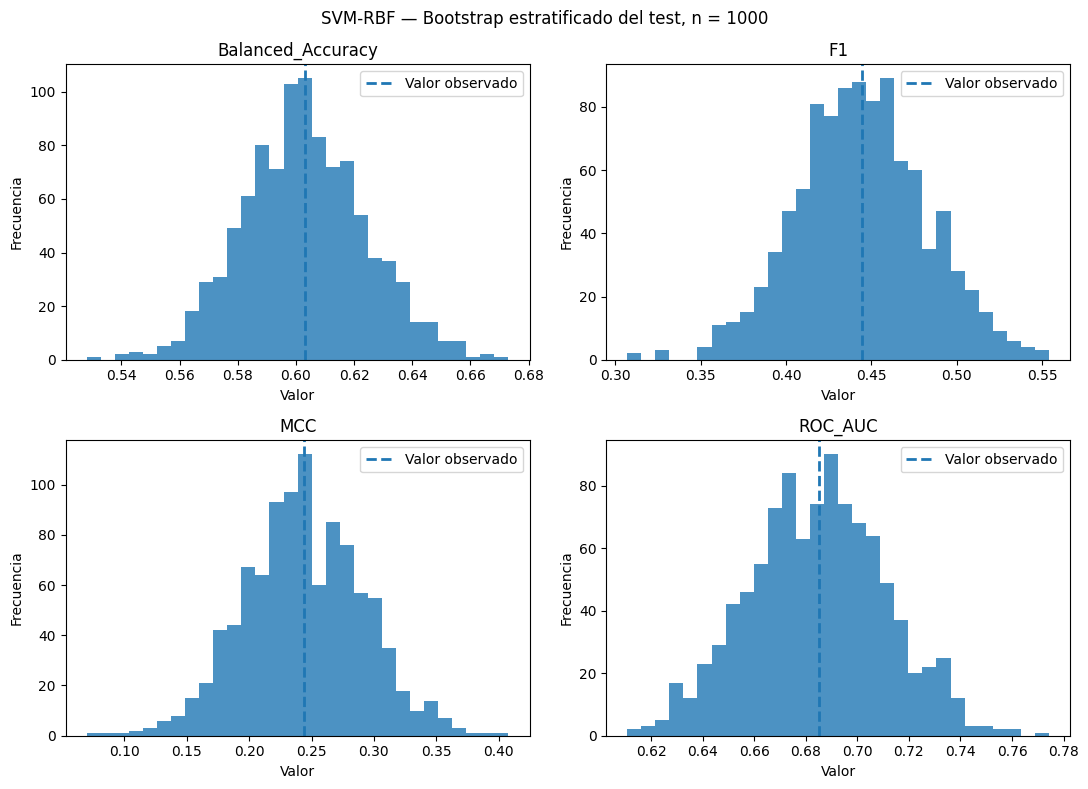

In [ ]:
#Distribuciones del boostrap
metrics_bootstrap_plot = [
    "Balanced_Accuracy",
    "F1",
    "MCC",
    "ROC_AUC",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8),
)

axes = axes.ravel()

for ax, metric in zip(
    axes,
    metrics_bootstrap_plot,
):

    ax.hist(
        bootstrap_results[metric],
        bins=30,
        alpha=0.80,
    )

    ax.axvline(
        observed_values[metric],
        linestyle="--",
        linewidth=2,
        label="Valor observado",
    )

    ax.set_title(metric)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.suptitle(
    "SVM-RBF — Bootstrap estratificado del test, n = 1000"
)

plt.tight_layout()
plt.show()

In [ ]:
#Calculamos el famoso yrandommization para comprobar si la relación entre las 4 variables y potabilidad produce un rendimento mayor que el obtenido al destruir de manera aleatoria los labels
N_SCRAMBLING = 1000

rng_scrambling = np.random.default_rng(
    SEED + 1
)

y_train_array = np.asarray(
    y_train,
    dtype=int,
)

scrambling_rows = []

for scramble_id in range(N_SCRAMBLING):

    y_train_scrambled = rng_scrambling.permutation(
        y_train_array
    )

    scrambled_model = clone(
        baseline_svm
    )

    scrambled_model.fit(
        X_train,
        y_train_scrambled,
    )

    y_scrambled_pred = scrambled_model.predict(
        X_test
    )

    y_scrambled_score = scrambled_model.decision_function(
        X_test
    )

    scrambling_rows.append({
        "Scramble_ID": scramble_id + 1,

        "Accuracy":
            accuracy_score(
                y_test,
                y_scrambled_pred,
            ),

        "Balanced_Accuracy":
            balanced_accuracy_score(
                y_test,
                y_scrambled_pred,
            ),

        "Precision":
            precision_score(
                y_test,
                y_scrambled_pred,
                zero_division=0,
            ),

        "Recall":
            recall_score(
                y_test,
                y_scrambled_pred,
                zero_division=0,
            ),

        "F1":
            f1_score(
                y_test,
                y_scrambled_pred,
                zero_division=0,
            ),

        "MCC":
            matthews_corrcoef(
                y_test,
                y_scrambled_pred,
            ),

        "ROC_AUC":
            roc_auc_score(
                y_test,
                y_scrambled_score,
            ),
    })

scrambling_results = pd.DataFrame(
    scrambling_rows
)

print(
    "Permutaciones completadas:",
    len(scrambling_results)
)

Permutaciones completadas: 1000


,Metric,Observed,Null_Mean,Null_SD,Null_95%,Empirical_p
0,Accuracy,0.6526,0.5951,0.0065,0.6055,0.0010
1,Balanced_Accuracy,0.6030,0.5023,0.0069,0.5142,0.0010
2,Precision,0.6292,0.4504,0.3150,1.0000,0.2747
3,Recall,0.3436,0.0163,0.0160,0.0491,0.0010
4,F1,0.4444,0.0309,0.0292,0.0894,0.0010
5,MCC,0.2438,0.0184,0.0526,0.1051,0.0010
6,ROC_AUC,0.6852,0.5184,0.0375,0.5815,0.0010


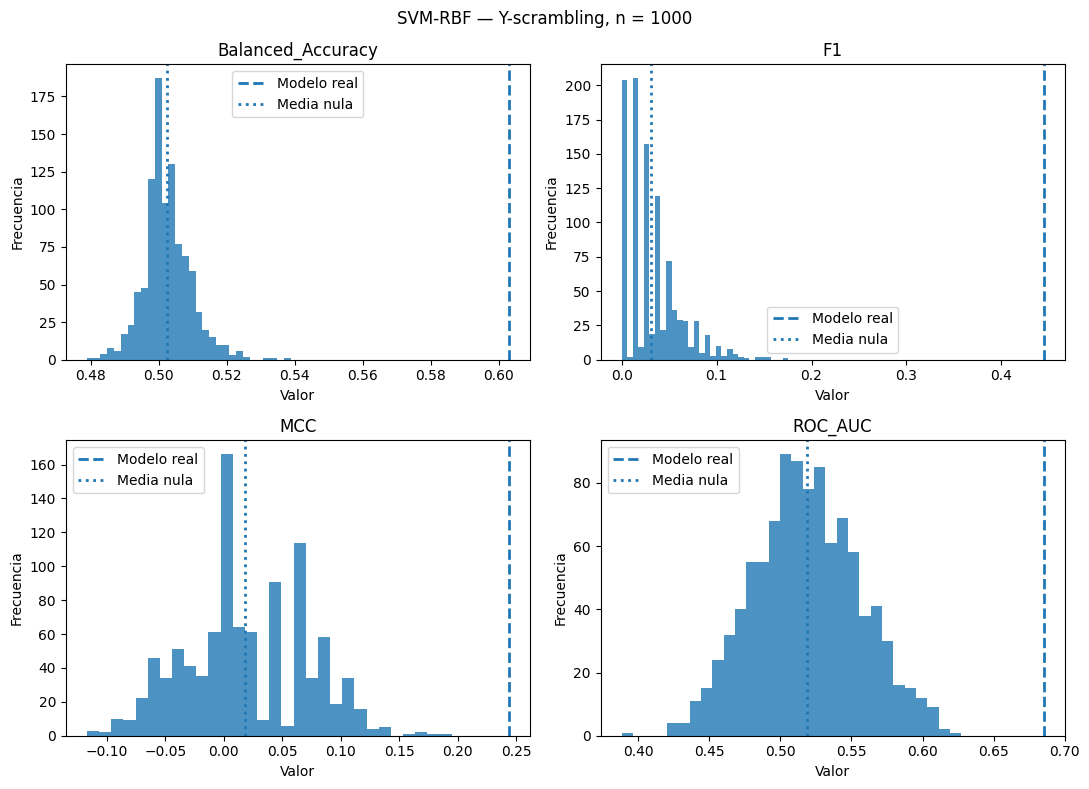

In [ ]:
#Pvalores del yscrambli ng p =1000+11+#(scrambled≥observado)​
scrambling_metrics = [
    "Accuracy",
    "Balanced_Accuracy",
    "Precision",
    "Recall",
    "F1",
    "MCC",
    "ROC_AUC",
]

scrambling_summary_rows = []

for metric in scrambling_metrics:

    null_values = scrambling_results[
        metric
    ].to_numpy()

    observed = observed_values[
        metric
    ]

    empirical_p = (
        1
        + np.sum(
            null_values >= observed
        )
    ) / (
        N_SCRAMBLING + 1
    )

    scrambling_summary_rows.append({
        "Metric": metric,
        "Observed": observed,
        "Null_Mean": null_values.mean(),
        "Null_SD": null_values.std(ddof=1),
        "Null_95%": np.percentile(
            null_values,
            95,
        ),
        "Empirical_p": empirical_p,
    })

scrambling_summary = pd.DataFrame(
    scrambling_summary_rows
)

display(
    scrambling_summary.round(4)
)
metrics_scrambling_plot = [
    "Balanced_Accuracy",
    "F1",
    "MCC",
    "ROC_AUC",
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(11, 8),
)

axes = axes.ravel()

for ax, metric in zip(
    axes,
    metrics_scrambling_plot,
):

    ax.hist(
        scrambling_results[metric],
        bins=30,
        alpha=0.80,
    )

    ax.axvline(
        observed_values[metric],
        linestyle="--",
        linewidth=2,
        label="Modelo real",
    )

    ax.axvline(
        scrambling_results[metric].mean(),
        linestyle=":",
        linewidth=2,
        label="Media nula",
    )

    ax.set_title(metric)
    ax.set_xlabel("Valor")
    ax.set_ylabel("Frecuencia")
    ax.legend()

plt.suptitle(
    "SVM-RBF — Y-scrambling, n = 1000"
)

plt.tight_layout()
plt.show()

##Validación externa DEF

In [ ]:
#Requisitos previos o configuración final
FINAL_C = 1.0
FINAL_GAMMA = "scale"
FINAL_CLASS_WEIGHT = None

FINAL_FEATURES = [
    "ph",
    "Hardness",
    "Sulfate",
    "Conductivity",
]

print("Configuración congelada")
print("C:", FINAL_C)
print("gamma:", FINAL_GAMMA)
print("class_weight:", FINAL_CLASS_WEIGHT)
print("features:", FINAL_FEATURES)

Configuración congelada
C: 1.0
gamma: scale
class_weight: None
features: ['ph', 'Hardness', 'Sulfate', 'Conductivity']


In [ ]:
#Cargamos el modelo fina
X_development = (
    df_model[FINAL_FEATURES]
    .copy()
)

y_development = (
    df_model[TARGET]
    .astype(int)
    .copy()
)

X_external = (
    df_ircach_21[FINAL_FEATURES]
    .copy()
)

y_external = (
    df_ircach_21[TARGET]
    .astype(int)
    .copy()
)

final_svm_external = Pipeline(
    steps=[
        (
            "variance",
            VarianceThreshold(
                threshold=0.0
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "svm",
            SVC(
                kernel="rbf",
                C=FINAL_C,
                gamma=FINAL_GAMMA,
                class_weight=FINAL_CLASS_WEIGHT,
                probability=False,
                random_state=SEED,
            ),
        ),
    ]
)

final_svm_external.fit(
    X_development,
    y_development,
)

print("Modelo reajustado con todo el desarrollo.")
print("Development:", X_development.shape)
print("External:", X_external.shape)

Modelo reajustado con todo el desarrollo.
Development: (2011, 4)
External: (21, 4)


In [ ]:
#Brier
external_calibration_cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED,
)

final_calibrated_external = CalibratedClassifierCV(
    estimator=clone(final_svm_external),
    method="sigmoid",
    cv=external_calibration_cv,
    n_jobs=-1,
)

final_calibrated_external.fit(
    X_development,
    y_development,
)

print("Calibración completada usando solo Kaggle.")

Calibración completada usando solo Kaggle.


In [ ]:
#Predicción IRcarch o dataset externo que tenemos
y_external_pred = final_svm_external.predict(
    X_external
)

y_external_score = final_svm_external.decision_function(
    X_external
)

y_external_probability = (
    final_calibrated_external
    .predict_proba(X_external)[:, 1]
)

print("Predicciones externas completadas.")
print("Número de muestras:", len(y_external_pred))

Predicciones externas completadas.
Número de muestras: 21


,Dataset,Accuracy,Balanced_Accuracy,Precision,Recall,Specificity,F1,MCC,ROC_AUC,Brier_Score,Unsafe_Acceptance_Rate,TN,FP,FN,TP
0,IRCACH_CR_EXT_21,0.5238,0.5833,1.0000,0.1667,1.0000,0.2857,0.2810,0.6111,0.2457,0.0000,9,0,10,2


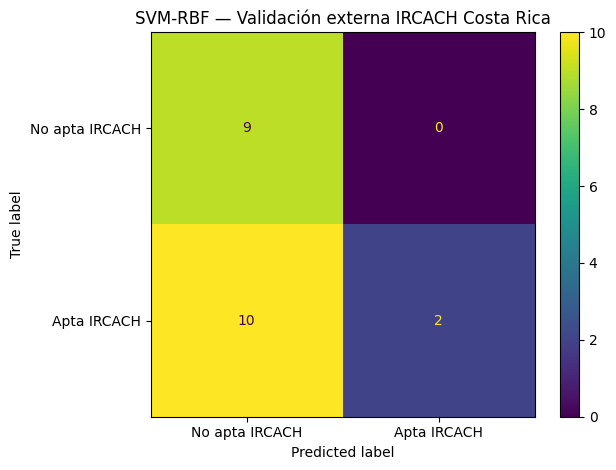

                precision    recall  f1-score   support

No apta IRCACH     0.4737    1.0000    0.6429         9
   Apta IRCACH     1.0000    0.1667    0.2857        12

      accuracy                         0.5238        21
     macro avg     0.7368    0.5833    0.4643        21
  weighted avg     0.7744    0.5238    0.4388        21



In [ ]:
#Métrica entre otras
external_tn, external_fp, external_fn, external_tp = (
    confusion_matrix(
        y_external,
        y_external_pred,
        labels=[0, 1],
    ).ravel()
)

external_specificity = (
    external_tn
    / (external_tn + external_fp)
)

external_unsafe_acceptance = (
    external_fp
    / (external_tn + external_fp)
)

external_results = pd.DataFrame(
    [
        {
            "Dataset": "IRCACH_CR_EXT_21",

            "Accuracy":
                accuracy_score(
                    y_external,
                    y_external_pred,
                ),

            "Balanced_Accuracy":
                balanced_accuracy_score(
                    y_external,
                    y_external_pred,
                ),

            "Precision":
                precision_score(
                    y_external,
                    y_external_pred,
                    zero_division=0,
                ),

            "Recall":
                recall_score(
                    y_external,
                    y_external_pred,
                    zero_division=0,
                ),

            "Specificity":
                external_specificity,

            "F1":
                f1_score(
                    y_external,
                    y_external_pred,
                    zero_division=0,
                ),

            "MCC":
                matthews_corrcoef(
                    y_external,
                    y_external_pred,
                ),

            "ROC_AUC":
                roc_auc_score(
                    y_external,
                    y_external_score,
                ),

            "Brier_Score":
                brier_score_loss(
                    y_external,
                    y_external_probability,
                ),

            "Unsafe_Acceptance_Rate":
                external_unsafe_acceptance,

            "TN": external_tn,
            "FP": external_fp,
            "FN": external_fn,
            "TP": external_tp,
        }
    ]
)

display(
    external_results.round(4)
)

ConfusionMatrixDisplay.from_predictions(
    y_external,
    y_external_pred,
    labels=[0, 1],
    display_labels=[
        "No apta IRCACH",
        "Apta IRCACH",
    ],
    values_format="d",
)

plt.title(
    "SVM-RBF — Validación externa IRCACH Costa Rica"
)

plt.tight_layout()
plt.show()

print(
    classification_report(
        y_external,
        y_external_pred,
        target_names=[
            "No apta IRCACH",
            "Apta IRCACH",
        ],
        digits=4,
        zero_division=0,
    )
)

In [ ]:
#Holyshit, si logramos tenemos señal predictiva. Ahora hacemos una tablita de prediccioens
def assign_error_type(
    true_label,
    predicted_label,
):

    if true_label == 0 and predicted_label == 0:
        return "Correcta_no_apta"

    if true_label == 1 and predicted_label == 1:
        return "Correcta_apta"

    if true_label == 0 and predicted_label == 1:
        return "Aceptacion_insegura"

    return "Rechazo_conservador"


external_predictions = (
    df_ircach_21
    .copy()
)

external_predictions[
    "Predicted_Potability"
] = y_external_pred

external_predictions[
    "Decision_Score"
] = y_external_score

external_predictions[
    "Probability_Potable"
] = y_external_probability

external_predictions[
    "Correct"
] = (
    external_predictions["Potability"]
    ==
    external_predictions["Predicted_Potability"]
)

external_predictions[
    "Error_Type"
] = [
    assign_error_type(
        true_label,
        predicted_label,
    )
    for true_label, predicted_label
    in zip(
        external_predictions["Potability"],
        external_predictions["Predicted_Potability"],
    )
]

print(
    external_predictions[
        "Error_Type"
    ].value_counts()
)

display_columns = [
    column
    for column in [
        "External_ID",
        "AYA_ID",
        "system_name",
        "sampling_point",
        "IRCACH_score",
        "IRCACH_risk_level",
        "ph",
        "Hardness",
        "Sulfate",
        "Conductivity",
        "Potability",
        "Predicted_Potability",
        "Probability_Potable",
        "Decision_Score",
        "Error_Type",
    ]
    if column in external_predictions.columns
]

display(
    external_predictions[
        display_columns
    ]
    .sort_values(
        [
            "Error_Type",
            "Probability_Potable",
        ],
        ascending=[
            True,
            False,
        ],
    )
    .round(4)
)

Error_Type
Rechazo_conservador    10
Correcta_no_apta        9
Correcta_apta           2
Name: count, dtype: int64


,External_ID,AYA_ID,system_name,sampling_point,IRCACH_score,IRCACH_risk_level,ph,Hardness,Sulfate,Conductivity,Potability,Predicted_Potability,Probability_Potable,Decision_Score,Error_Type
15,CR_IRCACH_023,AYA-ID-08939-2016,"CH-A-28-COLORADO, RAIZAL E HIGUERILLA",RAIZAL,3,Riesgo muy bajo,7.7600,195.0000,8.6600,448.0000,1,1,0.5423,0.0147,Correcta_apta
17,CR_IRCACH_025,AYA-ID-08735-2016,CH-A-38-PAPAGAYO SUR: HERMOSA - CACIQUE,HERMOSA,4,Riesgo muy bajo,8.2400,228.0000,6.6400,413.0000,1,1,0.5403,0.0040,Correcta_apta
20,CR_IRCACH_028,AYA-ID-07791-2016,HA-A-01-ACUEDUCTO INTEGRADO HONE CREEK – PUERT...,PUERTO VIEJO,14,Riesgo intermedio,7.6900,157.0000,11.6200,763.0000,0,0,0.5304,-0.0422,Correcta_no_apta
19,CR_IRCACH_027,AYA-ID-08247-2016,CH-A-56-CURUBANDÉ DE LIBERIA,RED 1,38,Riesgo muy alto,5.5000,95.0000,101.8100,263.0000,0,0,0.5303,-0.0435,Correcta_no_apta
0,CR_IRCACH_003,AYA-ID-06812-2016,SAN LUIS Y CAIMITOS DE FLORENCIA DE SAN CARLOS,RED 2,27,Riesgo alto,7.0800,56.0000,2.1300,103.0000,0,0,0.5289,-0.0492,Correcta_no_apta
5,CR_IRCACH_011,AYA-ID-05086-2016,CALLE HIGUERONES DE ESCAZÚ (No clorado),SECTOR CALLE A LA NACIENTE,35,Riesgo muy alto,7.8500,46.0000,7.2400,100.0000,0,0,0.5289,-0.0492,Correcta_no_apta
4,CR_IRCACH_010,AYA-ID-06567-2016,CALLE EL ALTO DE ESCAZÚ (No clorado),RED 2,27,Riesgo alto,7.7200,22.0000,22.1000,76.0000,0,0,0.5289,-0.0492,Correcta_no_apta
1,CR_IRCACH_004,AYA-ID-08736-2016,CH-A-38-PAPAGAYO SUR: HERMOSA - CACIQUE,PANAMÁ,44,Riesgo muy alto,7.4700,6367.0000,297.3300,11090.0000,0,0,0.5289,-0.0492,Correcta_no_apta
16,CR_IRCACH_024,AYA-ID-03720-2016,PAPAGAYO SUR-SISTEMA EL DUENDE,RED 2,34,Riesgo muy alto,7.1500,1088.0000,55.5000,2251.0000,0,0,0.5289,-0.0492,Correcta_no_apta
9,CR_IRCACH_017,AYA-ID-07493-2016,SANTA CECILIA DE SAN MARCOS DE TARRAZÚ,RED 2,43,Riesgo muy alto,4.4600,6.0000,17.9900,101.0000,0,0,0.5289,-0.0492,Correcta_no_apta
